In [2]:
# ============================
# SALES FORECASTING PROJECT
# FUTURE INTERNS - TASK 1
# ============================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All Libraries Imported Successfully ✅")

All Libraries Imported Successfully ✅


Upload Dataset

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


Load Dataset

In [9]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Verify Dataset

In [10]:
print("Shape:", df.shape)

Shape: (9994, 21)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Create a Backup

In [15]:
# Create a copy of the original dataset
df_clean = df.copy()

print("Backup Created Successfully ✅")

Backup Created Successfully ✅


View Column Names

In [16]:
df_clean.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Clean Column Names

In [17]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

Check Missing Values

In [18]:
df_clean.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [19]:
missing = df_clean.isnull().sum()

missing[missing > 0]

,0


Missing Value Percentage

In [20]:
missing_percent = (
    df_clean.isnull().sum()
    / len(df_clean)
    * 100
)

missing_percent

,0
row_id,0.0
order_id,0.0
order_date,0.0
ship_date,0.0
ship_mode,0.0
customer_id,0.0
customer_name,0.0
segment,0.0
country,0.0
city,0.0


Check Duplicate Rows

In [21]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [22]:
df_clean.dtypes

,0
row_id,int64
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_id,object
customer_name,object
segment,object
country,object
city,object


Convert Date Columns

In [23]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])

df_clean["ship_date"] = pd.to_datetime(df_clean["ship_date"])

Check Numeric Columns

In [24]:
df_clean.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Check Unique Categories

In [25]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    print("="*40)
    print(col)
    print(df_clean[col].unique())

order_id
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']
ship_mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']
customer_id
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925' 'KB-16585' 'SF-20065'
 'EB-13870' 'EH-13945' 'TB-21520' 'MA-17560' 'GH-14485' 'SN-20710'
 'LC-16930' 'RA-19885' 'ES-14080' 'ON-18715' 'PO-18865' 'LH-16900'
 'DP-13000' 'JM-15265' 'TB-21055' 'KM-16720' 'PS-18970' 'BS-11590'
 'KD-16270' 'HM-14980' 'JE-15745' 'KB-16600' 'SC-20770' 'DN-13690'
 'JC-16105' 'CS-12400' 'PG-18895' 'GM-14455' 'JS-15685' 'KB-16315'
 'RB-19705' 'PN-18775' 'KD-16345' 'ER-13855' 'RB-19465' 'GZ-14470'
 'LC-16870' 'JM-15250' 'PA-19060' 'CV-12805' 'CL-12565' 'RC-19960'
 'DK-13090' 'GG-14650' 'SC-20725' 'AD-10180' 'PF-19165' 'TS-21610'
 'LS-16975' 'DW-13585' 'LC-16885' 'JD-15895' 'SH-19975' 'SG-20080'
 'HA-14920' 'MG-17680' 'JE-16165' 'TW-21025' 'SP-20650' 'NK-1849

Check Dataset Shape

In [26]:
print(df_clean.shape)

(9994, 21)


Final Information

In [27]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

In [28]:
df_clean.to_csv("clean_superstore.csv", index=False)

In [29]:
from google.colab import files

files.download("clean_superstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

print("EDA Libraries Imported Successfully ✅")

EDA Libraries Imported Successfully ✅


In [31]:
df = pd.read_csv("clean_superstore.csv")

Dataset Overview

In [32]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

display(df.describe())

DATASET OVERVIEW
Rows: 9994
Columns: 21


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Sales Distribution

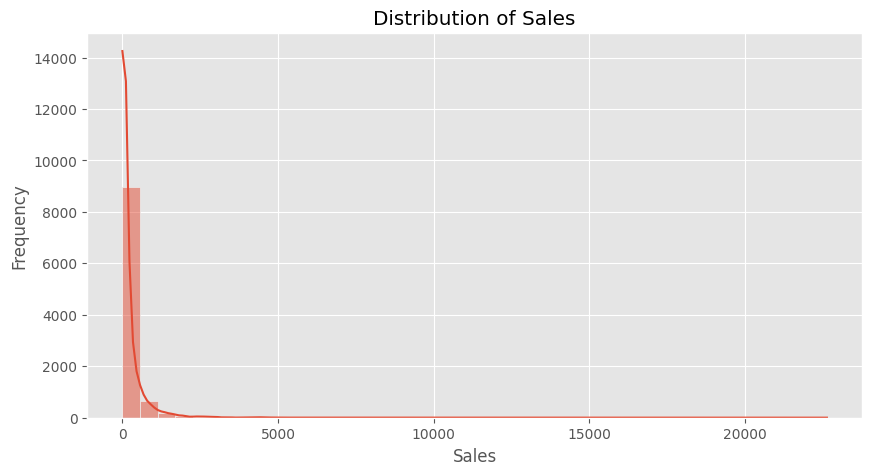

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(df["sales"], bins=40, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Profit Distribution

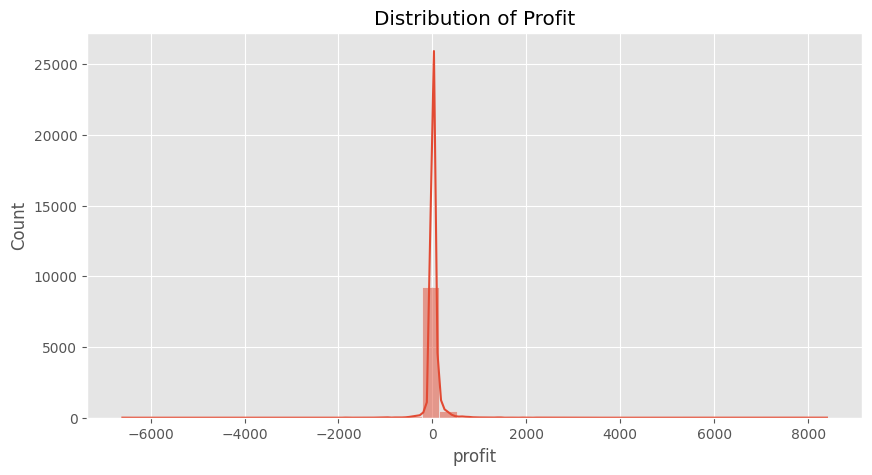

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(df["profit"], bins=40, kde=True)

plt.title("Distribution of Profit")

plt.show()

Category-wise Sales

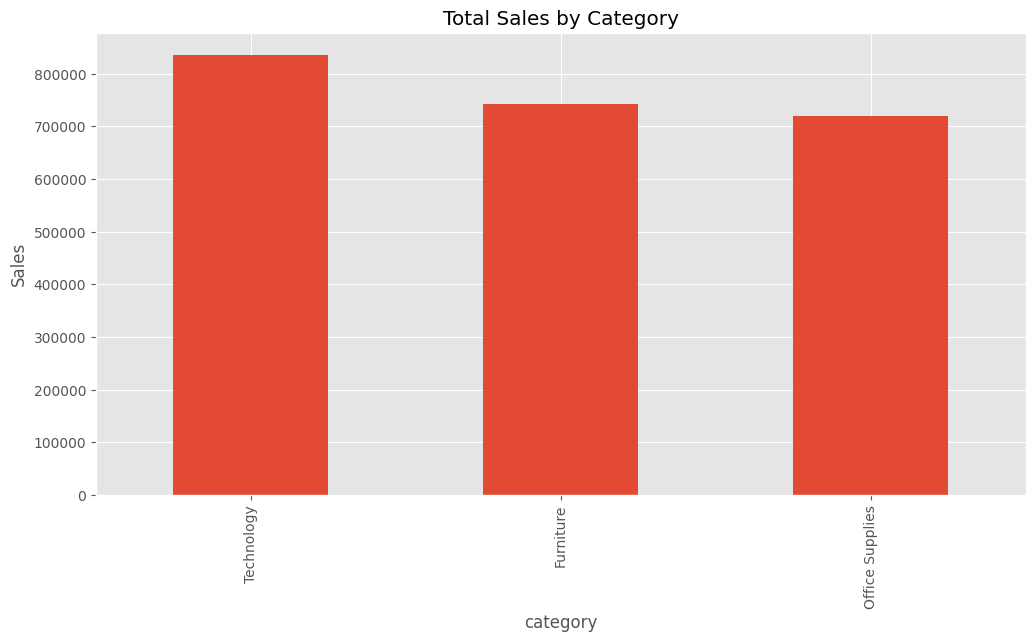

In [35]:
category_sales = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Sales")

plt.show()

Region-wise Sales

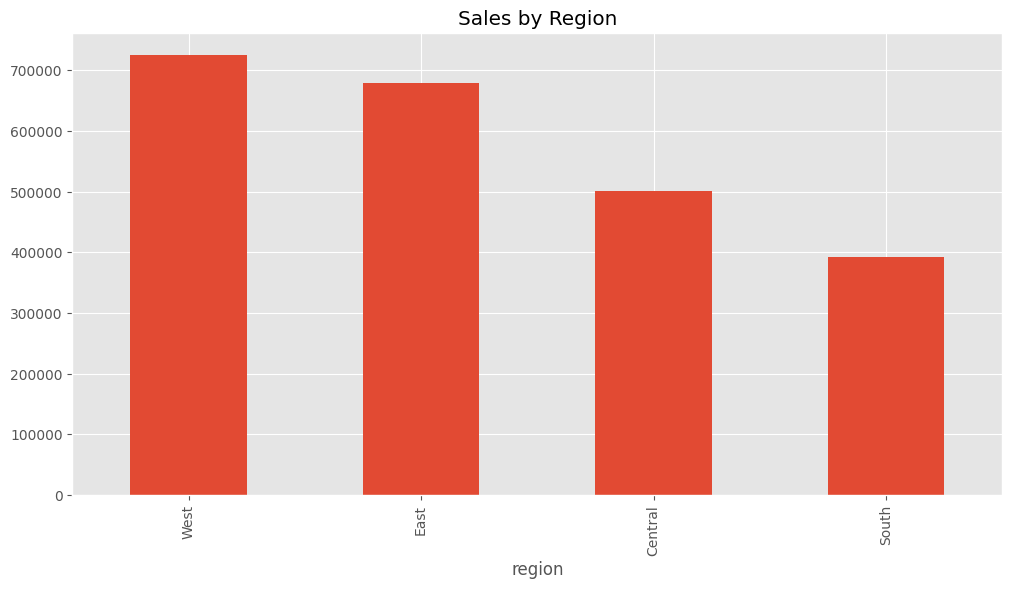

In [36]:
region_sales = (
    df.groupby("region")["sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.show()

Profit by Region

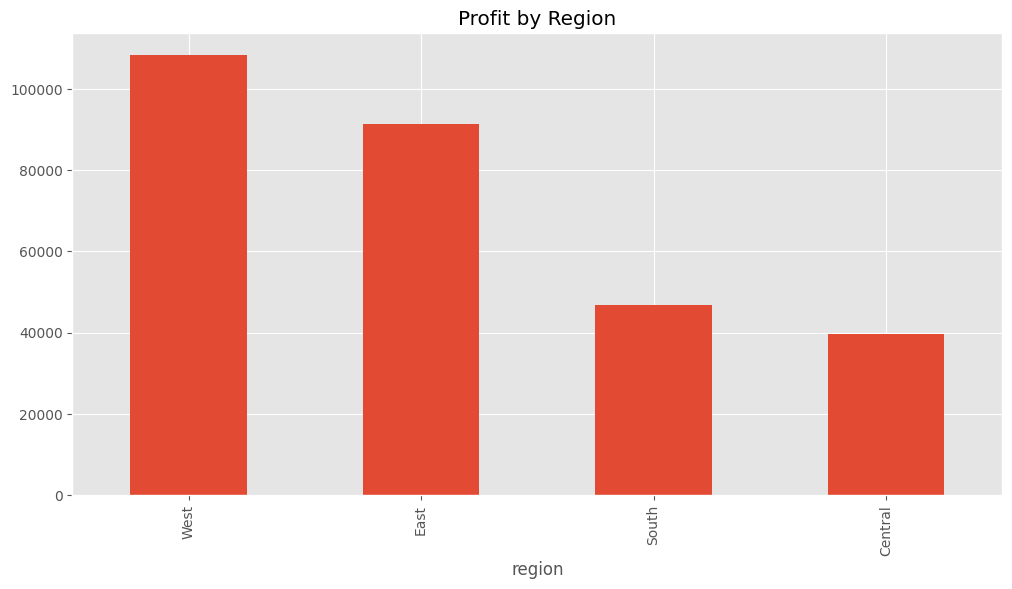

In [37]:
region_profit = (
    df.groupby("region")["profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit.plot(kind="bar")

plt.title("Profit by Region")

plt.show()

Monthly Sales Trend

In [39]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [40]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

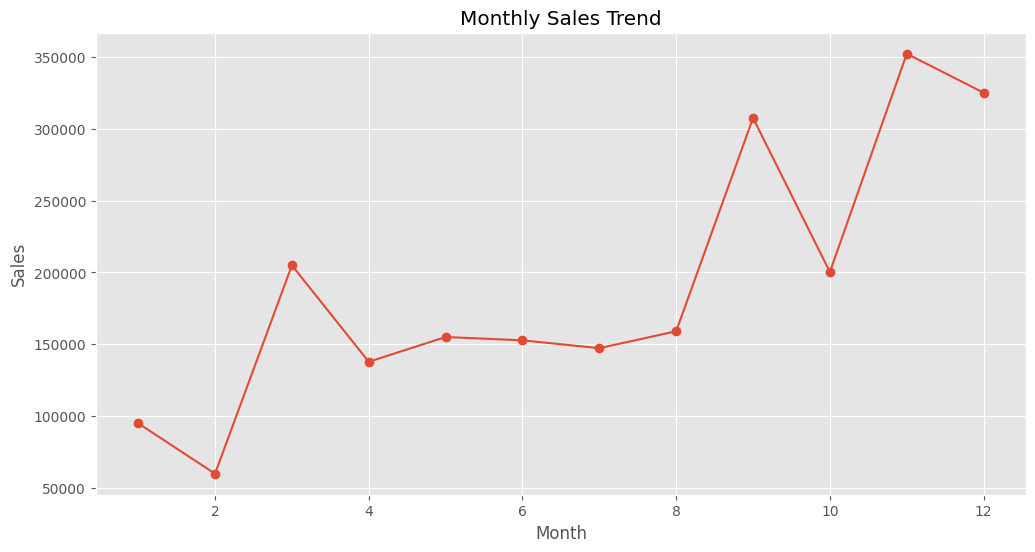

In [41]:
monthly_sales = (
    df.groupby("month")["sales"]
      .sum()
)

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

Yearly Sales

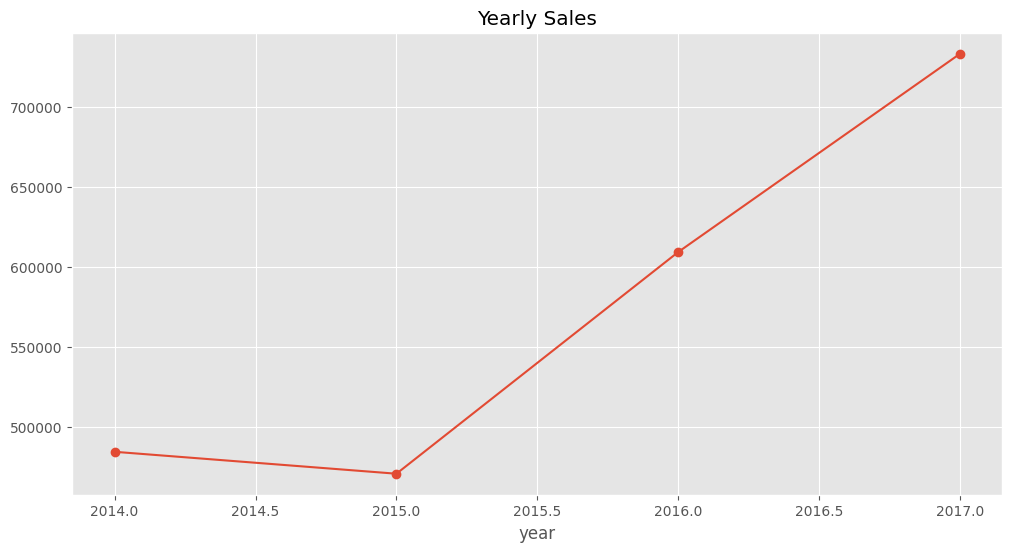

In [42]:
yearly_sales = (
    df.groupby("year")["sales"]
      .sum()
)

yearly_sales.plot(marker="o")

plt.title("Yearly Sales")

plt.show()

Top 10 Customers

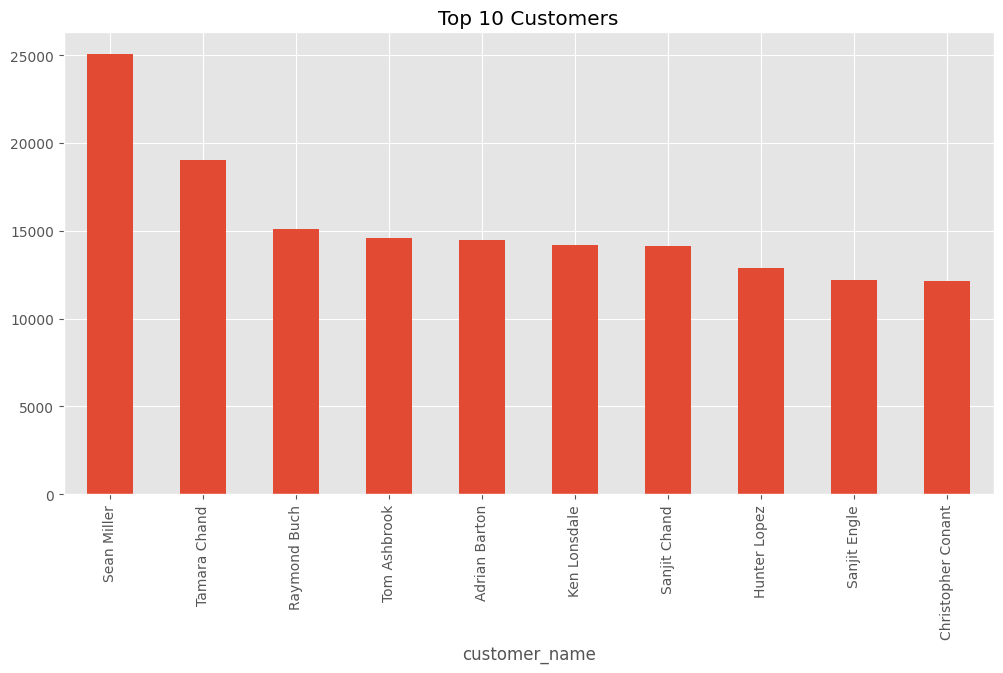

In [43]:
top_customers = (
    df.groupby("customer_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.show()

Top 10 Products

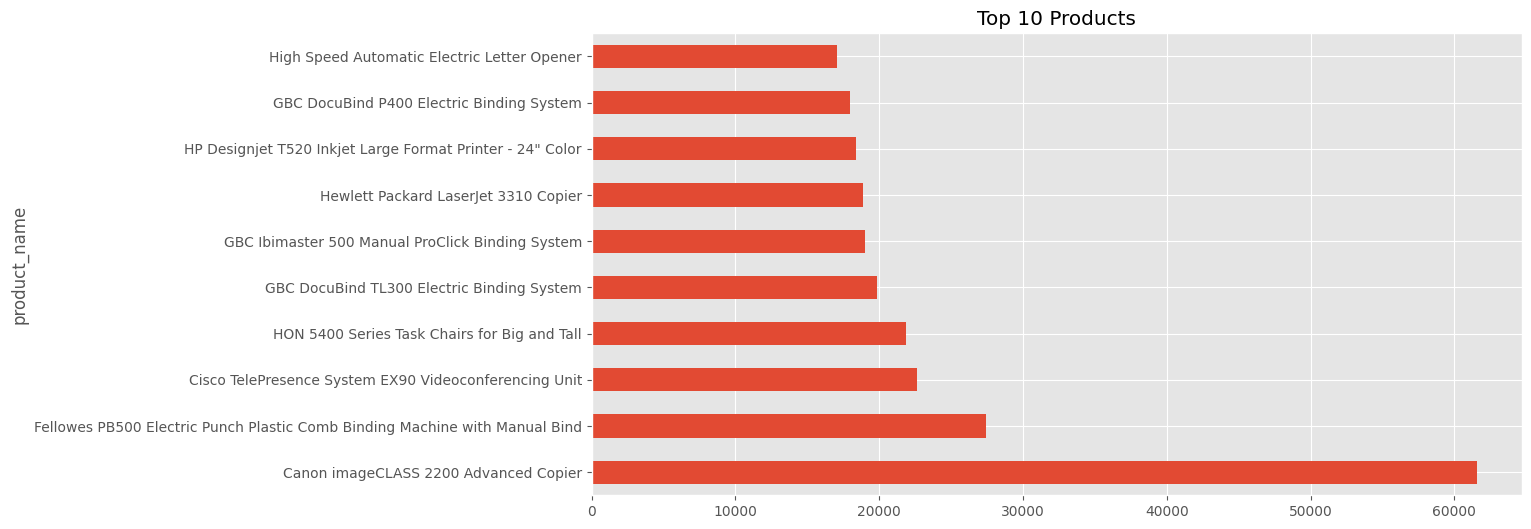

In [44]:
top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.show()

Correlation Heatmap

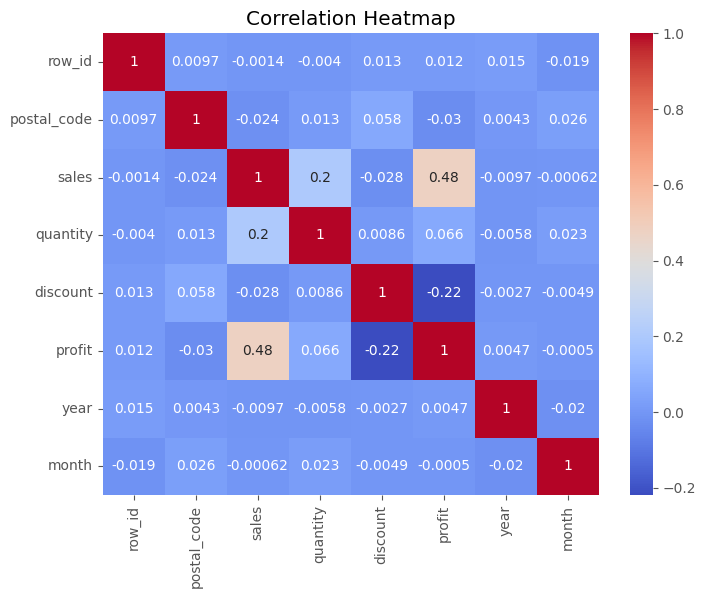

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Sales vs Profit

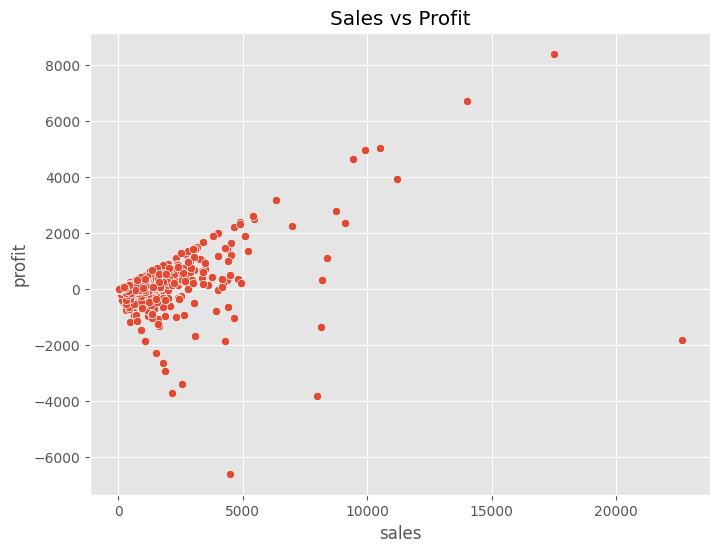

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit"
)

plt.title("Sales vs Profit")

plt.show()

In [47]:
plt.savefig("sales_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

In [48]:
# ==========================
# PHASE 5 - FEATURE ENGINEERING
# ==========================

df_ml = df.copy()

print("Working Copy Created Successfully ✅")

Working Copy Created Successfully ✅


In [49]:
df_ml.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'year',
 'month']

Convert Date Column

In [50]:
df_ml["order_date"] = pd.to_datetime(df_ml["order_date"])

In [51]:
df_ml["order_date"].dtype

dtype('<M8[ns]')

Create Time Feature

In [52]:
df_ml["year"] = df_ml["order_date"].dt.year
df_ml["month"] = df_ml["order_date"].dt.month
df_ml["day"] = df_ml["order_date"].dt.day
df_ml["day_of_week"] = df_ml["order_date"].dt.dayofweek
df_ml["quarter"] = df_ml["order_date"].dt.quarter
df_ml["week_of_year"] = df_ml["order_date"].dt.isocalendar().week.astype(int)

Drop Unnecessary Columns

In [53]:
drop_columns = [
    "row_id",
    "order_id",
    "customer_id",
    "customer_name",
    "product_name",
    "postal_code",
    "order_date",
    "ship_date"
]

df_ml.drop(columns=drop_columns, inplace=True, errors="ignore")

In [54]:
df_ml.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'region',
       'product_id', 'category', 'sub_category', 'sales', 'quantity',
       'discount', 'profit', 'year', 'month', 'day', 'day_of_week', 'quarter',
       'week_of_year'],
      dtype='object')

Encode Categorical Columns

In [55]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df_ml.select_dtypes(include="object").columns

for col in categorical_columns:
    df_ml[col] = label_encoder.fit_transform(df_ml[col])

In [56]:
df_ml.head()

,ship_mode,segment,country,city,state,region,product_id,category,sub_category,sales,quantity,discount,profit,year,month,day,day_of_week,quarter,week_of_year
0,2,0,0,194,15,2,12,0,4,261.9600,2,0.00,41.9136,2016,11,8,1,4,45
1,2,0,0,194,15,2,55,0,5,731.9400,3,0.00,219.5820,2016,11,8,1,4,45
2,2,1,0,266,3,3,946,1,10,14.6200,2,0.00,6.8714,2016,6,12,6,2,23
3,3,0,0,153,8,2,319,0,16,957.5775,5,0.45,-383.0310,2015,10,11,6,4,41
4,3,0,0,153,8,2,1316,1,14,22.3680,2,0.20,2.5164,2015,10,11,6,4,41


Select Target Variable

In [57]:
target = "sales"

In [58]:
X = df_ml.drop(columns=[target])

y = df_ml[target]

In [59]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (9994, 18)
Target Shape : (9994,)


Train-Test Split

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [61]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (7995, 18)
Testing Features : (1999, 18)
Training Labels : (7995,)
Testing Labels : (1999,)


In [62]:
df_ml.to_csv("feature_engineered_data.csv", index=False)

In [63]:
from google.colab import files

files.download("feature_engineered_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
# ===================================
# PHASE 6 - MODEL BUILDING
# ===================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import joblib

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


Train Linear Regression

In [65]:
# Create Model

linear_model = LinearRegression()

# Train Model

linear_model.fit(X_train, y_train)

print("Linear Regression Trained Successfully ✅")

Linear Regression Trained Successfully ✅


Make Predictions

In [66]:
linear_predictions = linear_model.predict(X_test)

Evaluate Linear Regression

In [67]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_predictions)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)

print(f"MAE  : {linear_mae:.2f}")
print(f"MSE  : {linear_mse:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R2   : {linear_r2:.4f}")

LINEAR REGRESSION RESULTS
MAE  : 244.81
MSE  : 673175.81
RMSE : 820.47
R2   : -0.1396


Train Random Forest

In [68]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully ✅")

Random Forest Trained Successfully ✅


Random Forest Predictions

In [69]:
rf_predictions = rf_model.predict(X_test)

Evaluate Random Forest

In [70]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)

print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R2   : {rf_r2:.4f}")

RANDOM FOREST RESULTS
MAE  : 83.23
MSE  : 236074.47
RMSE : 485.87
R2   : 0.6003


Compare Models

In [71]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,244.807771,673175.810775,820.472919,-0.139625
1,Random Forest,83.231286,236074.466235,485.874949,0.600347


Find Best Model

In [72]:
best_model = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest,83.231286,236074.466235,485.874949,0.600347
0,Linear Regression,244.807771,673175.810775,820.472919,-0.139625


In [74]:
joblib.dump(rf_model, "sales_forecasting_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [75]:
from google.colab import files

files.download("sales_forecasting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
sample_prediction = rf_model.predict(X_test.iloc[[0]])

print("Predicted Sales:", sample_prediction[0])

print("Actual Sales:", y_test.iloc[0])

Predicted Sales: 330.17642499999965
Actual Sales: 563.808


Actual vs Predicted

In [77]:
comparison_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_predictions
})

comparison_df.head(10)

,Actual Sales,Predicted Sales
0,563.808,330.176425
1,36.672,34.207560
2,37.300,58.839320
3,212.058,488.105655
4,171.288,355.319325
5,99.136,51.502880
6,340.182,371.960202
7,17.380,18.023400
8,22.620,20.657175
9,71.632,136.924780


Actual vs Predicted Scatter Plot

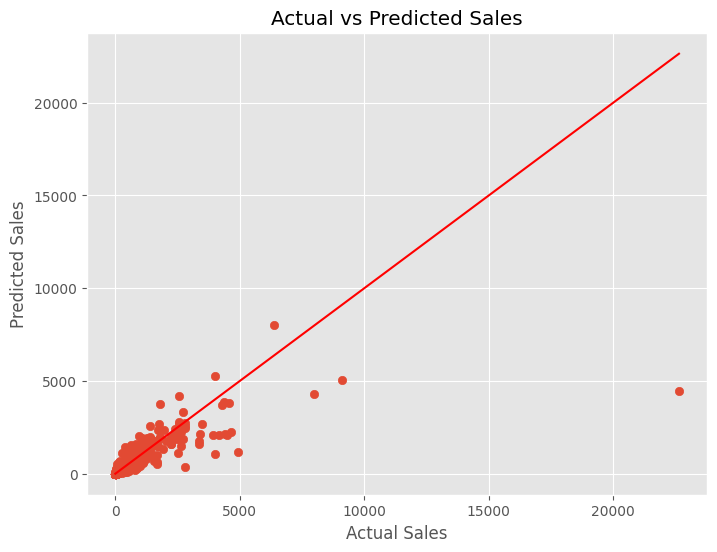

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

Feature Importance

In [79]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
11,profit,0.830510
6,product_id,0.038353
10,discount,0.030992
8,sub_category,0.024562
9,quantity,0.014988
14,day,0.008759
3,city,0.008315
4,state,0.007441
17,week_of_year,0.007340
15,day_of_week,0.005949


Plot Feature Importance

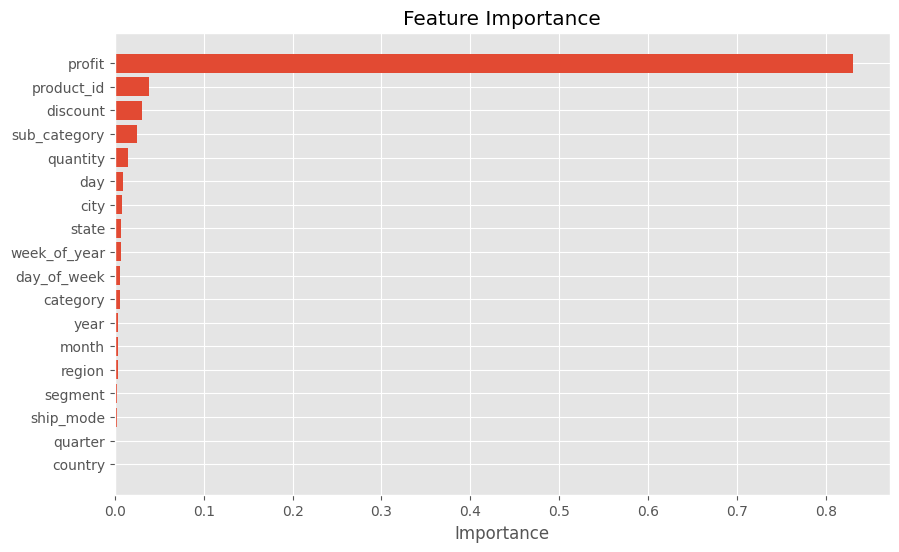

In [80]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Find Last Date

In [81]:
print("Last Date :", df["order_date"].max())

Last Date : 2017-12-30 00:00:00


Generate Future Dates

In [82]:
future_dates = pd.date_range(
    start=df["order_date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_df = pd.DataFrame({
    "order_date": future_dates
})

future_df.head()

,order_date
0,2017-12-31
1,2018-01-01
2,2018-01-02
3,2018-01-03
4,2018-01-04


Create Date Features

In [83]:
future_df["year"] = future_df["order_date"].dt.year
future_df["month"] = future_df["order_date"].dt.month
future_df["day"] = future_df["order_date"].dt.day
future_df["day_of_week"] = future_df["order_date"].dt.dayofweek
future_df["quarter"] = future_df["order_date"].dt.quarter
future_df["week_of_year"] = future_df["order_date"].dt.isocalendar().week.astype(int)

Add Remaining Features

In [84]:
future_df["quantity"] = df["quantity"].mean()
future_df["discount"] = df["discount"].mean()
future_df["profit"] = df["profit"].mean()

In [85]:
future_df["category"] = df_ml["category"].mode()[0]
future_df["region"] = df_ml["region"].mode()[0]
future_df["segment"] = df_ml["segment"].mode()[0]
future_df["ship_mode"] = df_ml["ship_mode"].mode()[0]
future_df["sub_category"] = df_ml["sub_category"].mode()[0]

In [86]:
print(X_train.columns)

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'region',
       'product_id', 'category', 'sub_category', 'quantity', 'discount',
       'profit', 'year', 'month', 'day', 'day_of_week', 'quarter',
       'week_of_year'],
      dtype='object')


Match Training Features

In [88]:
print(X_train.columns.tolist())

['ship_mode', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub_category', 'quantity', 'discount', 'profit', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year']


In [89]:
print(future_df.columns.tolist())

['order_date', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'quantity', 'discount', 'profit', 'category', 'region', 'segment', 'ship_mode', 'sub_category']


In [91]:
# Add Missing Columns
future_df["country"] = df_ml["country"].mode()[0]
future_df["city"] = df_ml["city"].mode()[0]
future_df["state"] = df_ml["state"].mode()[0]
future_df["product_id"] = df_ml["product_id"].mode()[0]

In [92]:
future_df = future_df[X_train.columns]

In [93]:
future_predictions = rf_model.predict(future_df)

future_df["predicted_sales"] = future_predictions

future_df.head()

,ship_mode,segment,country,city,state,region,product_id,category,sub_category,quantity,discount,profit,year,month,day,day_of_week,quarter,week_of_year,predicted_sales
0,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2017,12,31,6,4,52,83.79184
1,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,1,0,1,1,83.05048
2,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,2,1,1,1,82.99960
3,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,3,2,1,1,82.97732
4,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,4,3,1,1,83.02420


Create Forecast Table

In [94]:
forecast_table = future_df.copy()

forecast_table.head(10)

,ship_mode,segment,country,city,state,region,product_id,category,sub_category,quantity,discount,profit,year,month,day,day_of_week,quarter,week_of_year,predicted_sales
0,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2017,12,31,6,4,52,83.79184
1,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,1,0,1,1,83.05048
2,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,2,1,1,1,82.99960
3,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,3,2,1,1,82.97732
4,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,4,3,1,1,83.02420
5,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,5,4,1,1,82.99568
6,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,6,5,1,1,82.93348
7,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,7,6,1,1,83.13120
8,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,8,0,1,2,83.24868
9,3,0,0,329,3,3,1144,1,3,3.789574,0.156203,28.656896,2018,1,9,1,1,2,83.20232


Forecast Graph

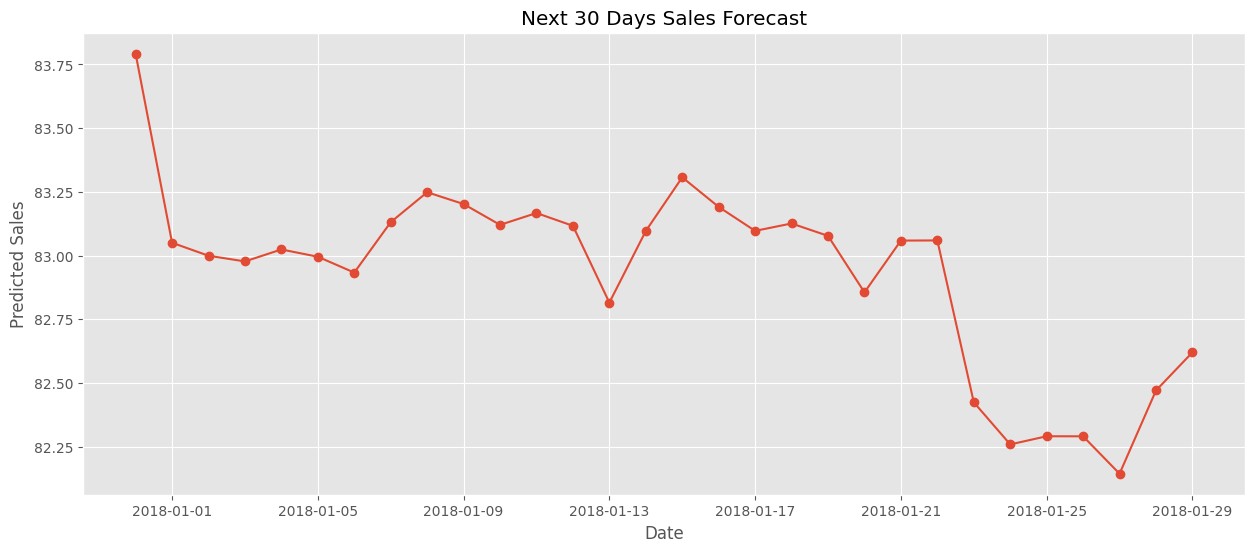

In [95]:
plt.figure(figsize=(15,6))

plt.plot(
    future_dates,
    future_predictions,
    marker="o"
)

plt.title("Next 30 Days Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

In [96]:
forecast_table.to_csv(
    "future_sales_forecast.csv",
    index=False
)

print("Forecast Saved Successfully ✅")

Forecast Saved Successfully ✅


In [97]:
from google.colab import files

files.download("future_sales_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
print("="*50)
print("FORECAST SUMMARY")
print("="*50)

print("Maximum Predicted Sales :", future_predictions.max())

print("Minimum Predicted Sales :", future_predictions.min())

print("Average Predicted Sales :", future_predictions.mean())

FORECAST SUMMARY
Maximum Predicted Sales : 83.79184000000004
Minimum Predicted Sales : 82.1446799999999
Average Predicted Sales : 82.93164533333326
